In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import pandas as pd

data_file = 'vodafone_music_subset.csv'
dictionary_file = 'Feature_dictionary.xlsx'

data = pd.read_csv(data_file)
feature_dict = pd.read_excel(dictionary_file, sheet_name=None)
data.head()

,device_type,manufacturer_category,os_category,sim_count,tp_flag,lt,block_flag,days_exp,service_1_flag,service_1_count,...,service_6_count_m3,service_7_cost_m3,service_7_flag_m3,service_8_count_m3,income_brnd_cont_m3,data_type_1_m3,data_type_2_m3,data_type_3_m3,service_9_flag_m3,target
0,7,1057,3,2.0,0,0.965306,0,153.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,48.779990,NaN,0
1,7,728,3,1.0,0,0.964468,0,354.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0
2,7,896,26,1.0,0,0.646706,0,60.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0
3,7,745,3,2.0,0,0.842123,0,252.0,1.0,22.0,...,0.0,0.0,0.0,0.0,NaN,NaN,3104.715068,2890.028280,NaN,1
4,7,69,27,1.0,1,0.988695,0,333.0,0.0,0.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.822502,41.871067,NaN,0


In [2]:
feature_table = feature_dict['Table']
feature_table_preview = feature_table.head()

feature_table_columns = feature_table.columns

In [10]:
clean_feature_table = feature_table.dropna(subset=['Unnamed: 1', 'Unnamed: 2']).iloc[1:]

clean_feature_table.columns = ['Data Type', 'Feature Name', 'Feature Description']
clean_feature_table.head()

,Data Type,Feature Name,Feature Description
3,NaN,id,ID
6,NaN,device_type,Device Type
7,NaN,manufacturer_category,Device Manufacturer
8,NaN,os_category,Device OS
9,NaN,sim_count,Number of sim card slots


In [11]:
data_summary = data.describe(include='all').transpose()

data_summary.head(15)

,count,mean,std,min,25%,50%,75%,max
device_type,17500.0,6.527486,1.205635,1.000000,7.000000,7.000000,7.000000,8.000000
manufacturer_category,17500.0,889.620343,492.099227,1.000000,592.000000,896.000000,1057.000000,1836.000000
os_category,17500.0,7.707429,9.554743,1.000000,3.000000,3.000000,3.000000,28.000000
sim_count,17324.0,1.607077,0.489712,1.000000,1.000000,2.000000,2.000000,3.000000
tp_flag,17500.0,0.082286,0.274807,0.000000,0.000000,0.000000,0.000000,1.000000
lt,17500.0,0.791303,0.155717,0.201879,0.701102,0.834245,0.919868,1.000000
block_flag,17500.0,0.026400,0.160326,0.000000,0.000000,0.000000,0.000000,1.000000
days_exp,17498.0,317.100297,80.530500,-87.000000,324.000000,345.000000,356.000000,824.000000
service_1_flag,17498.0,0.420562,0.493663,0.000000,0.000000,0.000000,1.000000,1.000000
service_1_count,17498.0,249.294662,445.107595,0.000000,0.000000,0.000000,387.000000,10760.000000


In [3]:
missing_values = data.isnull().sum().sort_values(ascending=False)

data_types = data.dtypes.value_counts()

target_distribution = data['target'].value_counts(normalize=True) * 100

print(missing_values)
print("#####") 
print(data_types) 
print("#####") 
print(target_distribution)


count_url_category_13    17379
count_url_category_15    17297
vol_app_3                17291
count_app_3              17291
count_url_category_12    17184
                         ...  
block_flag                   0
lt                           0
tp_flag                      0
os_category                  0
target                       0
Length: 460, dtype: int64
#####
float64    452
int64        8
Name: count, dtype: int64
#####
target
0    92.342857
1     7.657143
Name: proportion, dtype: float64


In [5]:
missing_ratio = data.isnull().mean().sort_values(ascending=False) * 100
high_missing_columns = missing_ratio[missing_ratio > 50].index
num_high_missing_columns = len(high_missing_columns)

print(missing_ratio)
print("########")
print(num_high_missing_columns)


count_url_category_13    99.308571
count_url_category_15    98.840000
vol_app_3                98.805714
count_app_3              98.805714
count_url_category_12    98.194286
                           ...    
block_flag                0.000000
lt                        0.000000
tp_flag                   0.000000
os_category               0.000000
target                    0.000000
Length: 460, dtype: float64
########
62


In [6]:
# Видаляємо колонки з великою часткою пропусків (>50%)
data_cleaned = data.drop(columns=high_missing_columns)

numeric_columns = data_cleaned.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = data_cleaned.select_dtypes(include=['object']).columns

data_cleaned[numeric_columns] = data_cleaned[numeric_columns].fillna(data_cleaned[numeric_columns].median())
if not categorical_columns.empty:
    data_cleaned[categorical_columns] = data_cleaned[categorical_columns].fillna(data_cleaned[categorical_columns].mode().iloc[0])

remaining_missing = data_cleaned.isnull().sum().sum()

print(remaining_missing)


0


In [7]:
for col in data_cleaned.select_dtypes(include=np.number).columns:
    df_encoded = pd.get_dummies(data_cleaned, drop_first=True)

In [43]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17500 entries, 0 to 17499
Columns: 398 entries, device_type to target
dtypes: float64(390), int64(8)
memory usage: 53.1 MB


In [8]:
df_cleansed = df_encoded.drop(columns=df_encoded.filter(regex='id|voice|calls|^sms|cost').columns)
df_cleansed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17500 entries, 0 to 17499
Columns: 104 entries, device_type to target
dtypes: float64(96), int64(8)
memory usage: 13.9 MB


In [48]:
#Статистичний огляд
df_cleansed.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
device_type,17500.0,6.527486,1.205635,1.000000,7.000000,7.000000,7.000000,8.000000
manufacturer_category,17500.0,889.620343,492.099227,1.000000,592.000000,896.000000,1057.000000,1836.000000
os_category,17500.0,7.707429,9.554743,1.000000,3.000000,3.000000,3.000000,28.000000
sim_count,17500.0,1.611029,0.488818,1.000000,1.000000,2.000000,2.000000,3.000000
tp_flag,17500.0,0.082286,0.274807,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...
service_7_flag_m3,17500.0,0.058629,0.383368,0.000000,0.000000,0.000000,0.000000,4.000000
service_8_count_m3,17500.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
data_type_2_m3,17500.0,1986.338894,5085.608988,0.000050,367.906835,643.236568,1149.504861,107707.651547
data_type_3_m3,17500.0,265.554134,818.820896,0.000031,16.690796,56.340131,147.004789,25739.826267


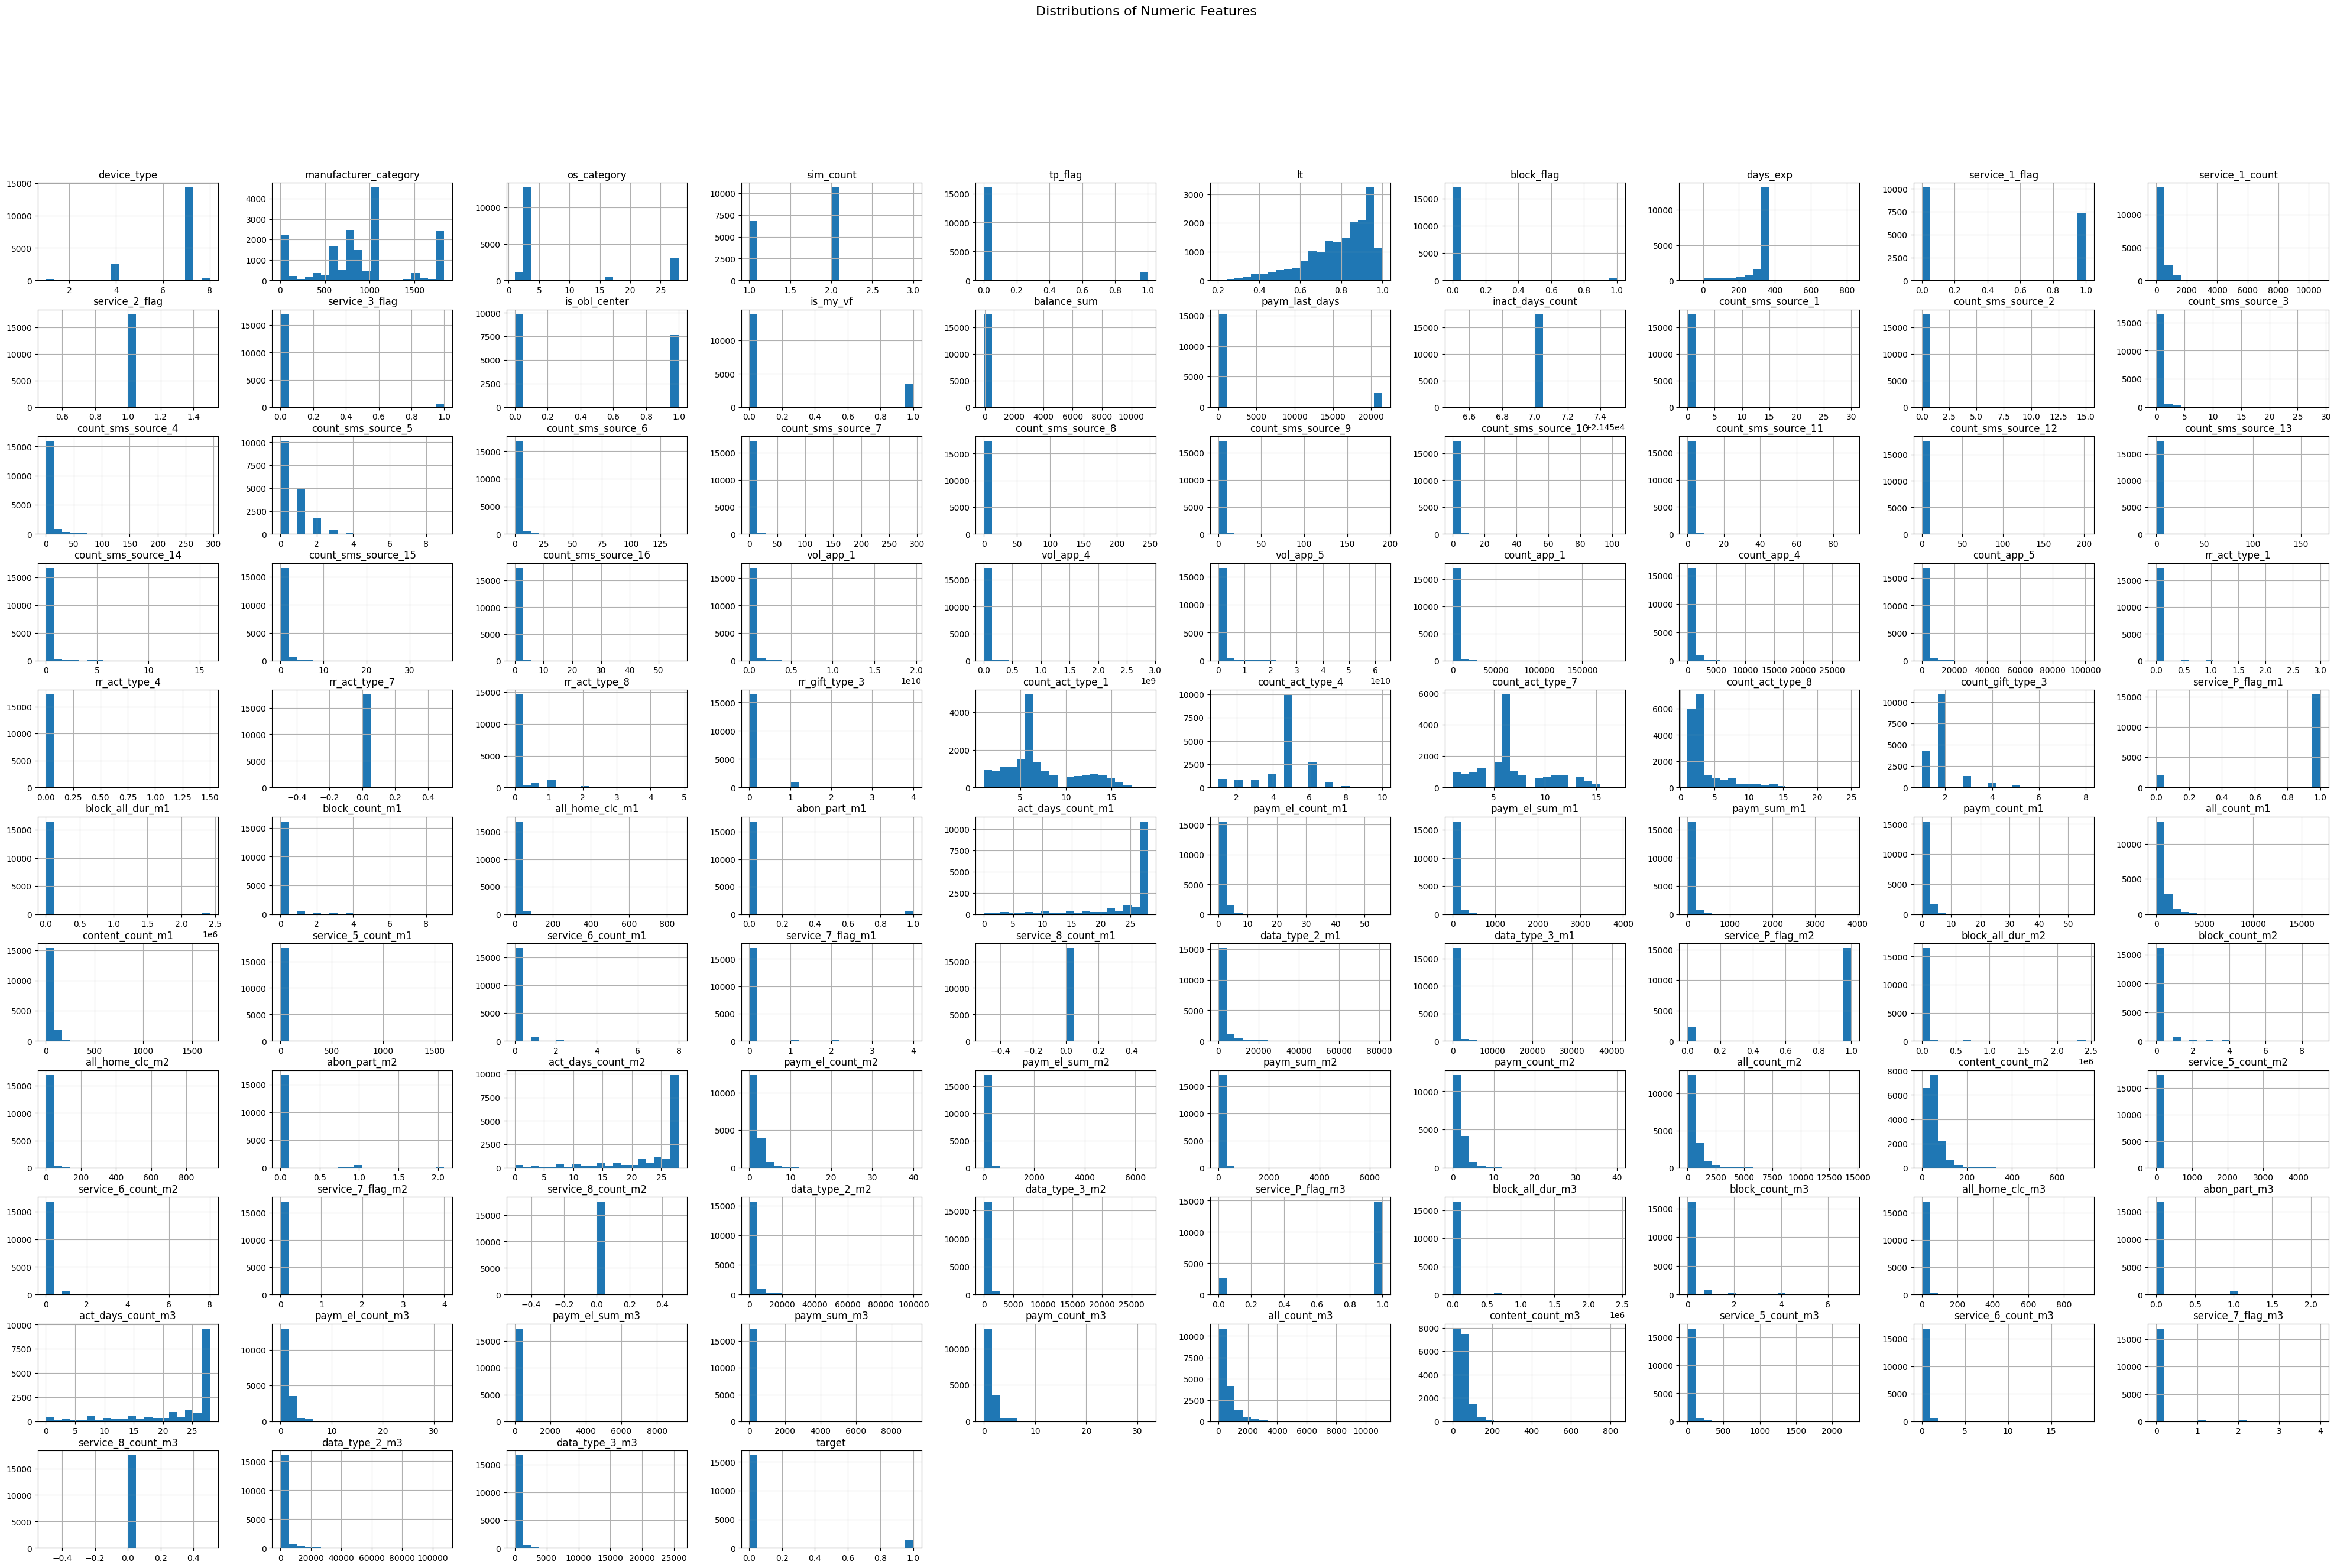

In [10]:
numeric_features = df_cleansed.select_dtypes(include=['float64', 'int64']).columns
df_cleansed[numeric_features].hist(figsize=(50, 30), bins=20)
plt.suptitle('Distributions of Numeric Features', fontsize=16)
plt.show()

In [49]:
correlations = df_cleansed.corr()['target'].sort_values(ascending=False)
print(correlations)

target                1.000000
content_count_m1      0.139147
content_count_m3      0.124602
content_count_m2      0.115864
count_gift_type_3     0.066235
                        ...   
inact_days_count           NaN
rr_act_type_7              NaN
service_8_count_m1         NaN
service_8_count_m2         NaN
service_8_count_m3         NaN
Name: target, Length: 104, dtype: float64


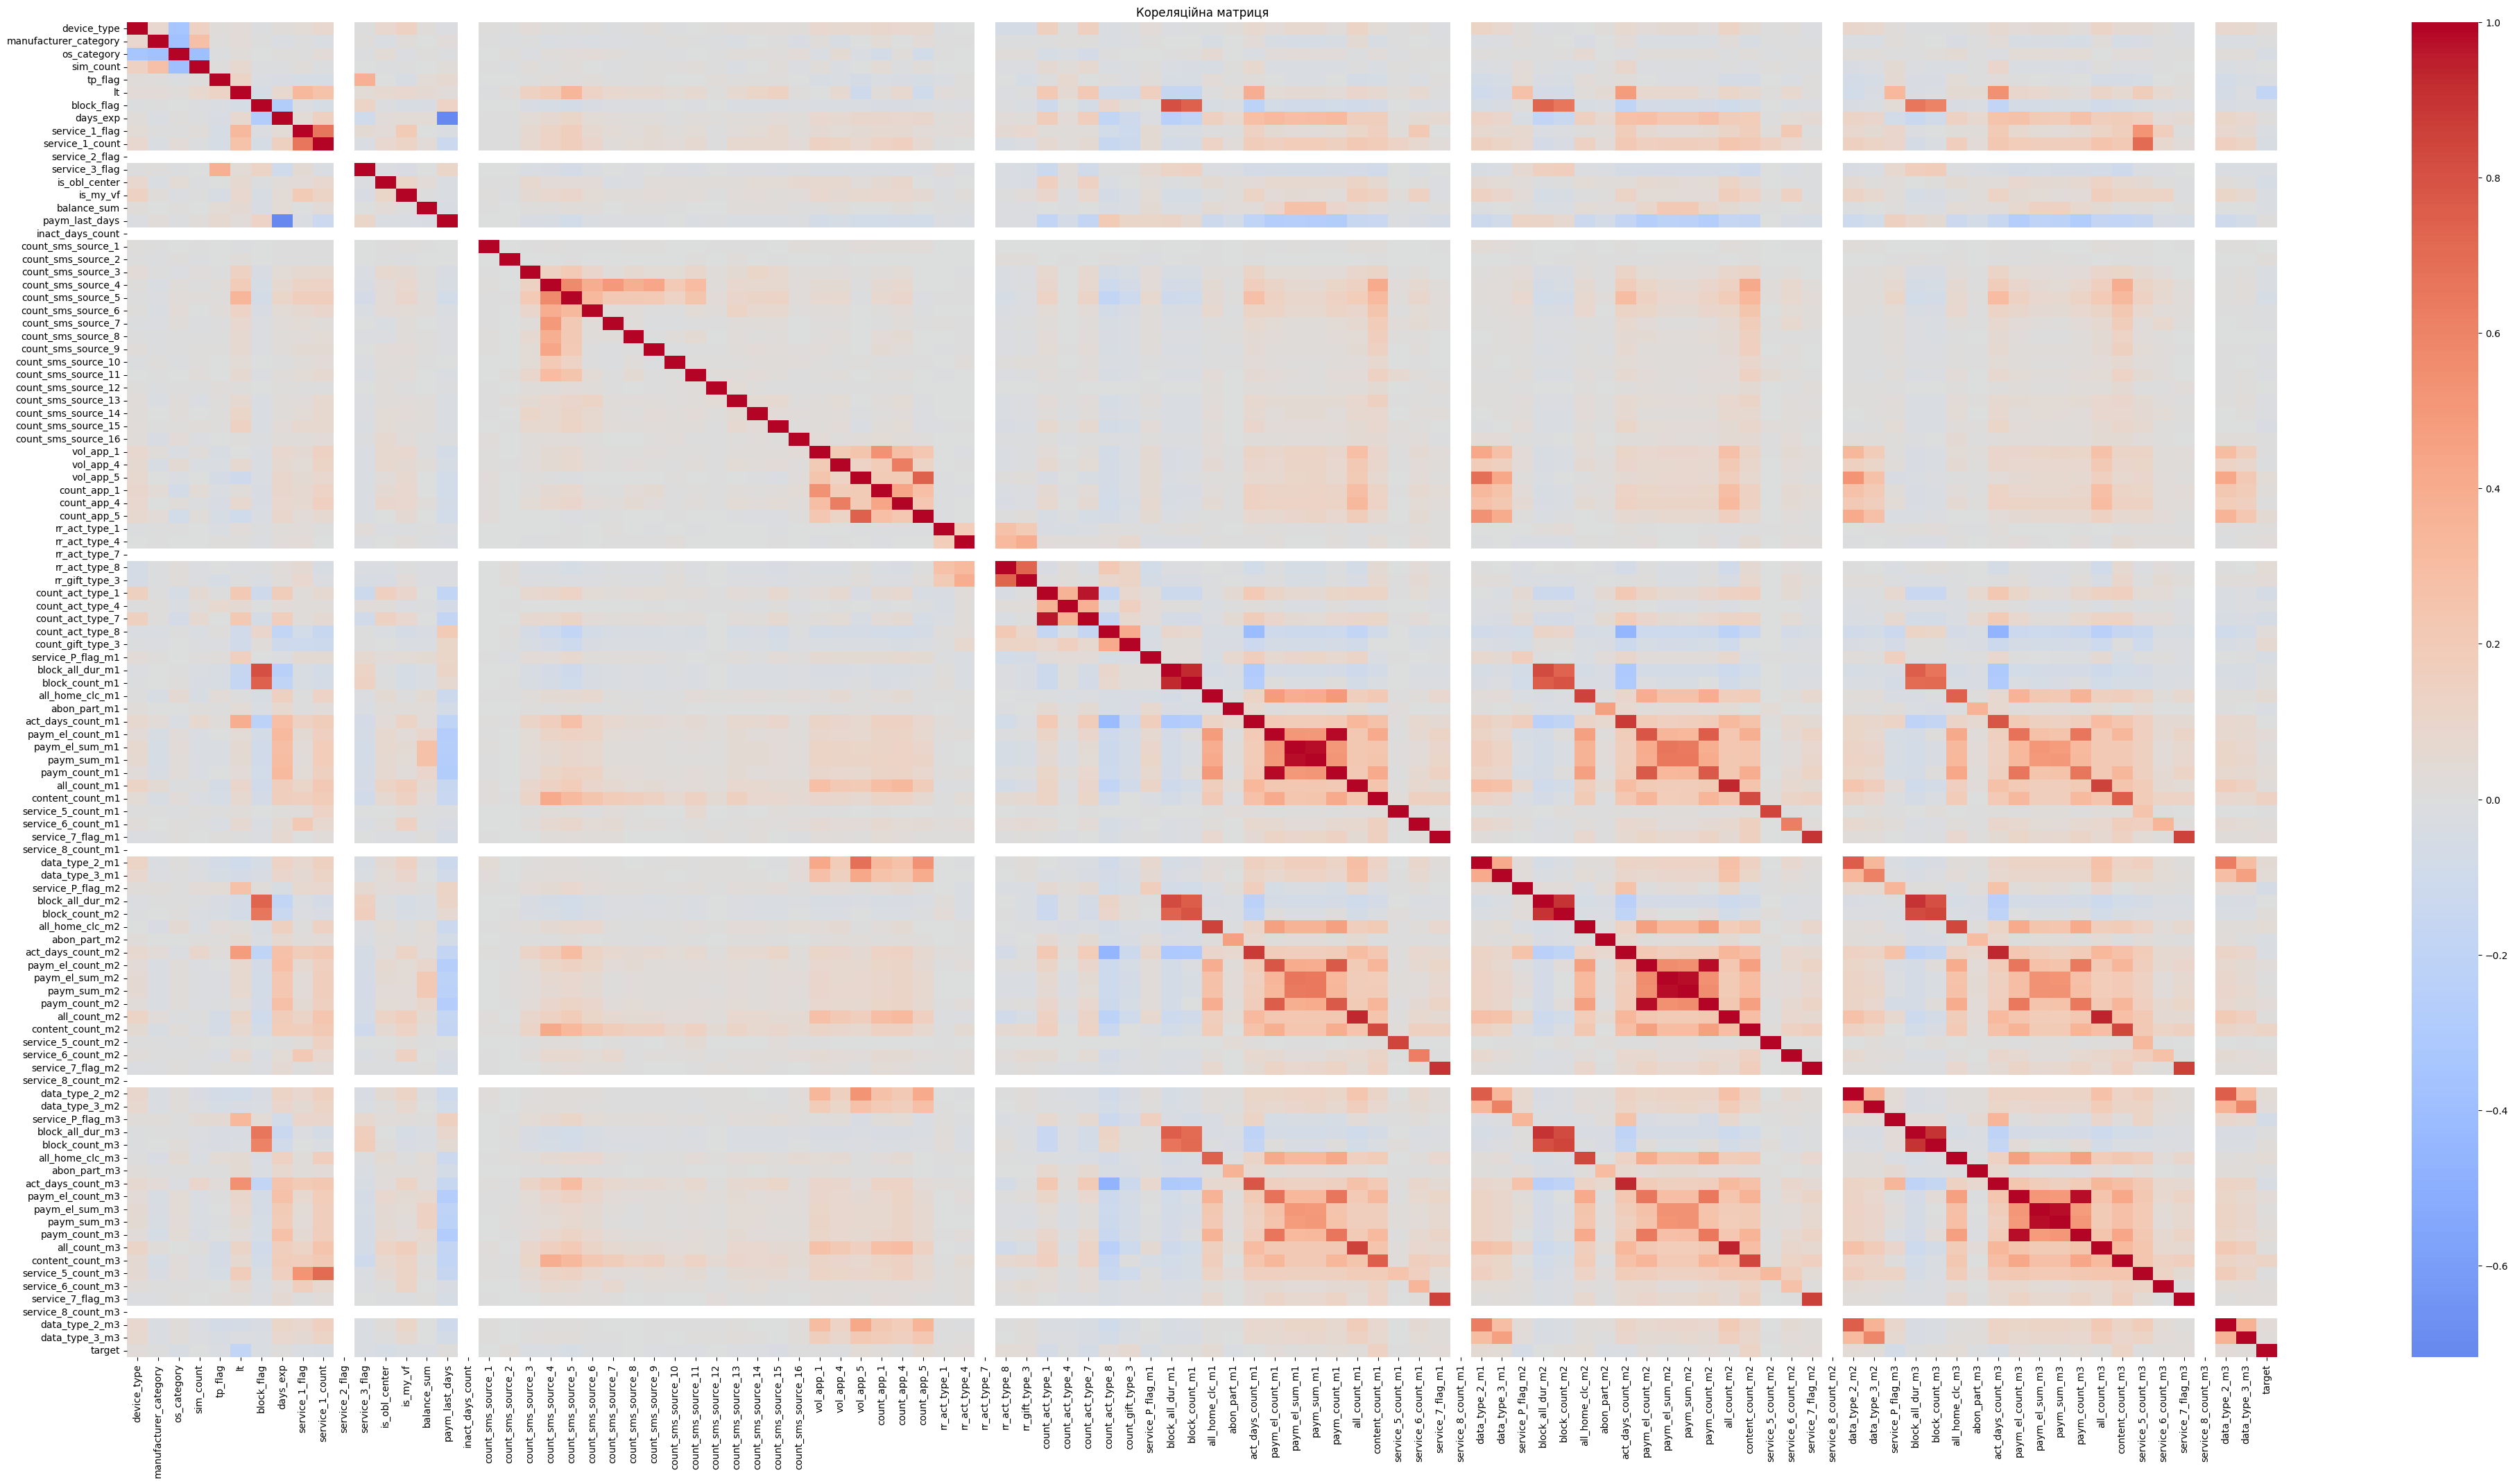

In [50]:
plt.figure(figsize=(50, 25))
sns.heatmap(df_cleansed.corr(), cmap='coolwarm', center=0, annot=False)
plt.title("Кореляційна матриця")
plt.show()


In [37]:
selected_features = correlations[correlations.abs() > 0.1].index.tolist()
selected_features.remove('target')  
print("Вибрані ознаки для моделі:", selected_features)

Вибрані ознаки для моделі: ['content_count_m1', 'content_count_m3', 'content_count_m2', 'lt']


In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, accuracy_score

def print_results(y_valid, y_pred):
    print('Precision:', precision_score(y_valid, y_pred))
    print('Recall:', recall_score(y_valid, y_pred))
    print('F1 score:', f1_score(y_valid, y_pred))
    print('ROC AUC score:', roc_auc_score(y_valid, y_pred))
    print('Accuracy score:', accuracy_score(y_valid, y_pred))
    print(confusion_matrix(y_valid, y_pred))

In [57]:
def plot_validation_curve(model_grid, param_name, params=None):
    results_df = pd.DataFrame(model_grid.cv_results_)    
    if params == None:
        plt.plot(results_df['param_'+param_name], results_df['mean_test_score'])
    else:
        plt.plot(params, results_df['mean_test_score'])
    plt.xlabel(param_name)
    plt.ylabel('Test F1 score')
    plt.title('Validation curve')
    plt.show()

In [52]:
from sklearn.model_selection import train_test_split

y = df_cleansed["target"]
X = df_cleansed.drop("target", axis=1)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=2021)

In [ ]:
Почнемо з дерева рішень DecisionTreeClassifier

In [61]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=2021)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_valid)
print_results(y_valid, y_pred)

Precision: 0.15897435897435896
Recall: 0.18787878787878787
F1 score: 0.17222222222222222
ROC AUC score: 0.5533955126044126
Accuracy score: 0.8637714285714285
[[3717  328]
 [ 268   62]]


Precision: 0.16225165562913907
Recall: 0.1484848484848485
F1 score: 0.15506329113924053
ROC AUC score: 0.5429692474809903
Accuracy score: 0.8779428571428571
[[3792  253]
 [ 281   49]]


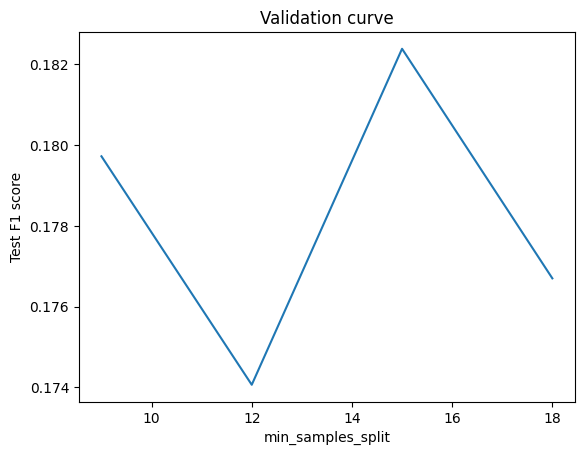

In [62]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

kf = KFold(n_splits=5, shuffle=True, random_state=2021) 
tree = DecisionTreeClassifier(random_state=2021)
tree_params={"min_samples_split": np.arange(9, 19, 3)} 
tree_grid = GridSearchCV(tree, tree_params, cv=kf, scoring='f1', n_jobs=-1) 
tree_grid.fit(X_train, y_train)

y_pred = tree_grid.best_estimator_.predict(X_valid)
print_results(y_valid, y_pred)
plot_validation_curve(tree_grid, "min_samples_split")

In [ ]:
Спробуємо застосувати метод knn

In [71]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)  
knn.fit(X_train, y_train)

y_pred = knn.predict(X_valid)
print_results(y_valid, y_pred)

Precision: 0.08571428571428572
Recall: 0.00909090909090909
F1 score: 0.01643835616438356
ROC AUC score: 0.5005899539274076
Accuracy score: 0.9179428571428572
[[4013   32]
 [ 327    3]]


Precision: 0.0743801652892562
Recall: 0.02727272727272727
F1 score: 0.039911308203991136
ROC AUC score: 0.49979211147319924
Accuracy score: 0.9010285714285714
[[3933  112]
 [ 321    9]]
Best parameters found:  {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


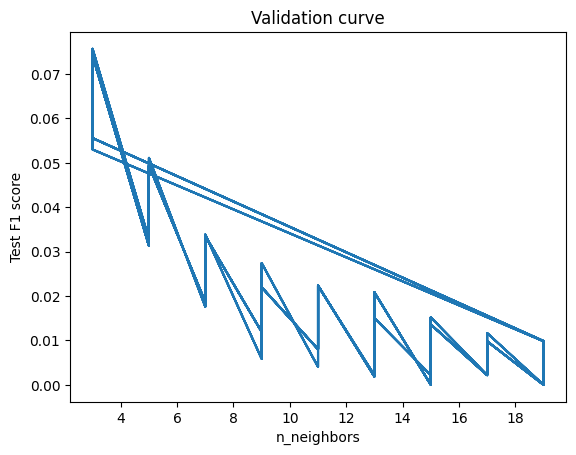

In [72]:
knn_params = {
    'n_neighbors': np.arange(3, 21, 2),  
    'weights': ['uniform', 'distance'], 
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 
    'metric': ['euclidean', 'manhattan', 'minkowski'] 
}

knn = KNeighborsClassifier()
kf = KFold(n_splits=5, shuffle=True, random_state=2021)
knn_grid = GridSearchCV(knn, knn_params, cv=kf, scoring='f1', n_jobs=-1)
knn_grid.fit(X_train, y_train)
y_pred = knn_grid.best_estimator_.predict(X_valid)

print_results(y_valid, y_pred)
print("Best parameters found: ", knn_grid.best_params_)
plot_validation_curve(knn_grid, "n_neighbors")

In [73]:
best_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    algorithm='auto',
    metric='manhattan'
)

best_knn.fit(X_train, y_train)

y_pred = best_knn.predict(X_valid)
print_results(y_valid, y_pred)

Precision: 0.0743801652892562
Recall: 0.02727272727272727
F1 score: 0.039911308203991136
ROC AUC score: 0.49979211147319924
Accuracy score: 0.9010285714285714
[[3933  112]
 [ 321    9]]


In [ ]:
Спробуємо застосувати бустинговий ансамбель

In [63]:
from sklearn.ensemble import AdaBoostClassifier

ab = AdaBoostClassifier(n_estimators=500, random_state=2021)
ab.fit(X_train, y_train)
y_pred = ab.predict(X_valid)
print_results(y_valid, y_pred)

Precision: 0.37142857142857144
Recall: 0.11818181818181818
F1 score: 0.1793103448275862
ROC AUC score: 0.5509326890661872
Accuracy score: 0.9184
[[3979   66]
 [ 291   39]]


Precision: 0.3711340206185567
Recall: 0.10909090909090909
F1 score: 0.1686182669789227
ROC AUC score: 0.5470052814923025
Accuracy score: 0.9188571428571428
[[3984   61]
 [ 294   36]]


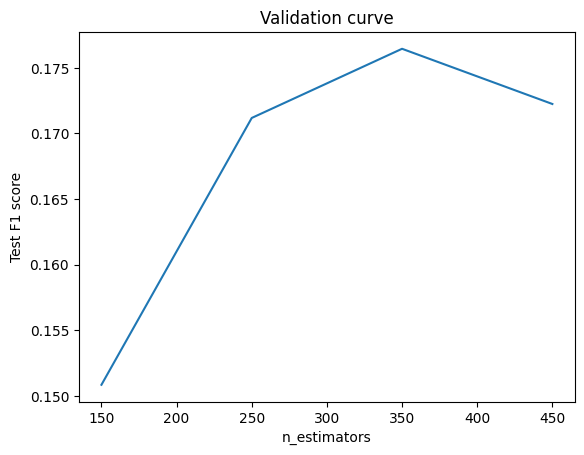

In [66]:
ab_params = {'n_estimators': np.arange(150, 501, 100)}
ab_grid = GridSearchCV(ab, ab_params, cv=kf, scoring='f1', n_jobs=-1)
ab_grid.fit(X_train, y_train)
y_pred = ab_grid.best_estimator_.predict(X_valid)
print_results(y_valid, y_pred)
plot_validation_curve(ab_grid, "n_estimators")

Precision: 0.32413793103448274
Recall: 0.14242424242424243
F1 score: 0.19789473684210523
ROC AUC score: 0.5590984005693523
Accuracy score: 0.9129142857142857
[[3947   98]
 [ 283   47]]


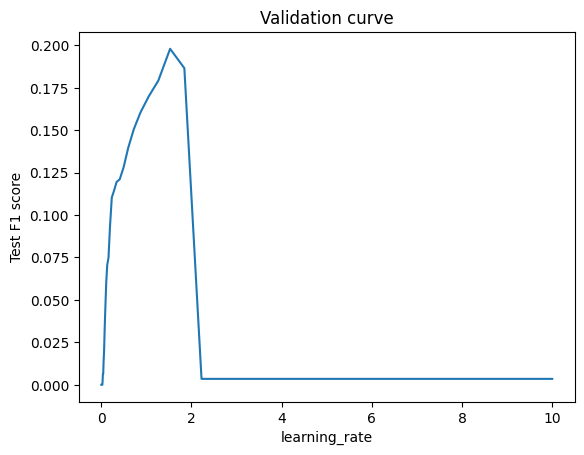

In [67]:
ab = AdaBoostClassifier(n_estimators=ab_grid.best_params_['n_estimators'], random_state=2021)

ab_params = {'learning_rate': np.logspace(-3, 1)}
ab_grid = GridSearchCV(ab, ab_params, cv=kf, scoring='f1', n_jobs=-1)
ab_grid.fit(X_train, y_train)
y_pred = ab_grid.best_estimator_.predict(X_valid)

print_results(y_valid, y_pred)
plot_validation_curve(ab_grid, "learning_rate")

In [68]:
import xgboost as xgb

xgbc = xgb.XGBClassifier(random_state=2021)
xgbc.fit(X_train, y_train)
y_pred = xgbc.predict(X_valid)

print_results(y_valid, y_pred)

Precision: 0.39473684210526316
Recall: 0.09090909090909091
F1 score: 0.14778325123152708
ROC AUC score: 0.5397685133161029
Accuracy score: 0.9209142857142857
[[3999   46]
 [ 300   30]]


c:\users\rex20\appdata\local\programs\python\python38\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Precision: 0.4305555555555556
Recall: 0.09393939393939393
F1 score: 0.154228855721393
ROC AUC score: 0.5419017118028243
Accuracy score: 0.9222857142857143
[[4004   41]
 [ 299   31]]


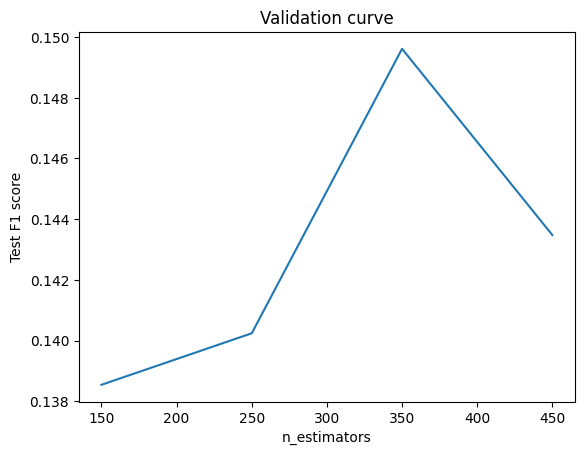

In [69]:
xgb_params = {'n_estimators': range(150, 501, 100)}
xgb_grid = GridSearchCV(xgbc, xgb_params, cv=kf, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
y_pred = xgb_grid.best_estimator_.predict(X_valid)

print_results(y_valid, y_pred)
plot_validation_curve(xgb_grid, 'n_estimators')

Precision: 0.336734693877551
Recall: 0.1
F1 score: 0.1542056074766355
ROC AUC score: 0.5419653893695922
Accuracy score: 0.9172571428571429
[[3980   65]
 [ 297   33]]


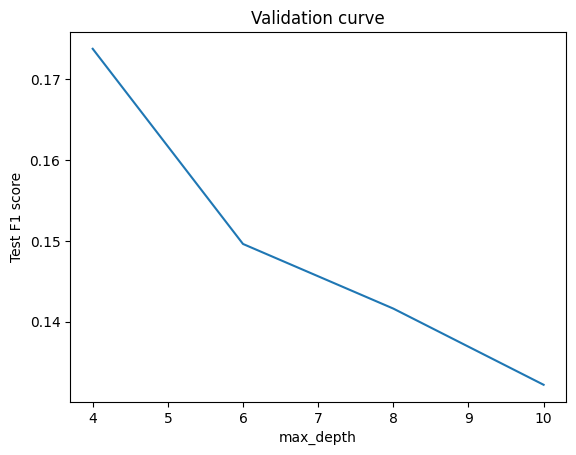

In [70]:
xgbc = xgb.XGBClassifier(n_estimators=xgb_grid.best_params_['n_estimators'], random_state=2021)
xgb_params = {'max_depth': [4, 6, 8, 10]}

xgb_grid = GridSearchCV(xgbc, xgb_params, cv=kf, scoring='f1', n_jobs=-1)
xgb_grid.fit(X_train, y_train)
y_pred = xgb_grid.best_estimator_.predict(X_valid)

print_results(y_valid, y_pred)
plot_validation_curve(xgb_grid, 'max_depth')